In [1]:
import pandas as pd
import numpy as np 

In [2]:
import os

data_path = "data"

events = pd.read_csv(os.path.join(data_path, "events.csv"))
inventory_events = pd.read_csv(os.path.join(data_path, "inventory_events.csv"))
order_items = pd.read_csv(os.path.join(data_path, "order_items.csv"))
orders = pd.read_csv(os.path.join(data_path, "orders.csv"))
products = pd.read_csv(os.path.join(data_path, "products.csv"))
users = pd.read_csv(os.path.join(data_path, "users.csv"))

#### EDA qua các bảng (information, view data)

In [3]:
print(events.shape)
# print(inventory_events.shape)
print(order_items.shape)
print(orders.shape)
print(products.shape)
print(users.shape)

(2420661, 13)
(180862, 11)
(124814, 9)
(29120, 9)
(100000, 15)


In [4]:
tables = [events, order_items, orders, products, users]

In [5]:
for table in tables:
    print(f'Some information about table:\n')
    print(table.info())
    print()

Some information about table:

<class 'pandas.DataFrame'>
RangeIndex: 2420661 entries, 0 to 2420660
Data columns (total 13 columns):
 #   Column           Dtype  
---  ------           -----  
 0   id               int64  
 1   user_id          float64
 2   sequence_number  int64  
 3   session_id       str    
 4   created_at       str    
 5   ip_address       str    
 6   city             str    
 7   state            str    
 8   postal_code      str    
 9   browser          str    
 10  traffic_source   str    
 11  uri              str    
 12  event_type       str    
dtypes: float64(1), int64(2), str(10)
memory usage: 553.4 MB
None

Some information about table:

<class 'pandas.DataFrame'>
RangeIndex: 180862 entries, 0 to 180861
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 180862 non-null  int64  
 1   order_id           180862 non-null  int64  
 2   user_id           

In [6]:
events['created_at'] = pd.to_datetime(events['created_at'], format='mixed', utc=True)

In [7]:
events.head()

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type
0,1437486,NaN,3,063af7a0-25c0-46c3-854b-2f3ec3d974ab,2019-04-26 16:02:00+00:00,156.42.243.148,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel
1,2172013,NaN,3,7aa618a9-218d-46d4-ba56-f37092575a06,2022-10-05 16:56:00+00:00,40.155.221.143,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel
2,1987970,NaN,3,1f918350-992c-49dd-82af-f3e72b8b94e4,2021-02-17 04:35:00+00:00,91.237.188.129,São Paulo,São Paulo,02675-031,Safari,Email,/cancel,cancel
3,2245378,NaN,3,8a99bc3c-f70b-4c9a-be26-5313bb226b34,2024-04-07 04:52:00+00:00,147.219.220.175,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel
4,1519935,NaN,3,a64f434d-d3f2-4261-a490-79d4743d81e4,2023-09-14 15:20:00+00:00,211.175.27.209,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel


In [8]:
print("Start date:", events['created_at'].min())
print("End date:", events['created_at'].max())

Start date: 2019-01-02 00:15:00+00:00
End date: 2024-05-13 17:53:48.103510+00:00


In [9]:
order_items['created_at'] = pd.to_datetime(order_items['created_at'], format='mixed', utc=True)
order_items['shipped_at'] = pd.to_datetime(order_items['shipped_at'], format='mixed', utc=True)
order_items['delivered_at'] = pd.to_datetime(order_items['delivered_at'], format='mixed', utc=True)
order_items['returned_at'] = pd.to_datetime(order_items['returned_at'], format='mixed', utc=True)

In [10]:
print("Start date:", order_items['created_at'].min())
print("End date:", order_items['created_at'].max())

Start date: 2019-01-09 03:58:22+00:00
End date: 2024-05-13 17:53:48.103510+00:00


In [11]:
order_items.head()

,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price
0,101104,69639,55545,14235,273075,Cancelled,2021-12-27 23:35:57+00:00,NaT,NaT,NaT,0.02
1,17970,12402,9819,14235,48492,Complete,2024-01-21 08:21:43+00:00,2024-01-19 18:09:00+00:00,2024-01-21 09:20:00+00:00,NaT,0.02
2,46481,32099,25651,14235,125372,Complete,2019-10-06 06:14:19+00:00,2019-10-03 13:08:00+00:00,2019-10-04 01:04:00+00:00,NaT,0.02
3,162654,112208,89828,14235,439099,Processing,2022-12-11 00:43:18+00:00,NaT,NaT,NaT,0.02
4,61938,42730,34156,14235,167190,Returned,2023-09-20 11:58:48+00:00,2023-09-23 14:58:00+00:00,2023-09-25 07:58:00+00:00,2023-09-28 00:40:00+00:00,0.02


In [12]:
orders['created_at'] = pd.to_datetime(orders['created_at'], format='mixed', utc=True)
orders['returned_at'] = pd.to_datetime(orders['returned_at'], format='mixed', utc=True)
orders['shipped_at'] = pd.to_datetime(orders['shipped_at'], format='mixed', utc=True)
orders['delivered_at'] = pd.to_datetime(orders['delivered_at'], format='mixed', utc=True)

In [13]:
orders.head()

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item
0,7,8,Cancelled,F,2023-09-06 10:43:00+00:00,NaT,NaT,NaT,1
1,40,36,Cancelled,F,2023-07-08 04:49:00+00:00,NaT,NaT,NaT,2
2,43,37,Cancelled,F,2023-12-04 05:29:00+00:00,NaT,NaT,NaT,1
3,59,50,Cancelled,F,2022-03-21 08:06:00+00:00,NaT,NaT,NaT,1
4,77,63,Cancelled,F,2024-02-04 15:21:00+00:00,NaT,NaT,NaT,1


In [14]:
products.head()

,id,cost,category,name,brand,retail_price,department,sku,distribution_center_id
0,13842,2.51875,Accessories,Low Profile Dyed Cotton Twill Cap - Navy W39S55D,MG,6.25,Women,EBD58B8A3F1D72F4206201DA62FB1204,1
1,13928,2.33835,Accessories,Low Profile Dyed Cotton Twill Cap - Putty W39S55D,MG,5.95,Women,2EAC42424D12436BDD6A5B8A88480CC3,1
2,14115,4.87956,Accessories,Enzyme Regular Solid Army Caps-Black W35S45D,MG,10.99,Women,EE364229B2791D1EF9355708EFF0BA34,1
3,14157,4.64877,Accessories,Enzyme Regular Solid Army Caps-Olive W35S45D (...,MG,10.99,Women,00BD13095D06C20B11A2993CA419D16B,1
4,14273,6.50793,Accessories,Washed Canvas Ivy Cap - Black W11S64C,MG,15.99,Women,F531DC20FDE20B7ADF3A73F52B71D0AF,1


In [15]:
users['created_at'] = pd.to_datetime(users['created_at'], format='mixed', utc=True)

In [16]:
print("Start date:", users['created_at'].min())
print("End date:", users['created_at'].max())

Start date: 2019-01-02 00:22:00+00:00
End date: 2024-05-08 19:30:30.371785+00:00


In [17]:
users.head()

,id,first_name,last_name,email,age,gender,state,street_address,postal_code,city,country,latitude,longitude,traffic_source,created_at
0,8142,Dean,Vance,deanvance@example.net,50,M,Acre,8821 Wolf Trail,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2022-10-30 17:46:00+00:00
1,24645,Michael,Turner,michaelturner@example.org,28,M,Acre,600 Monica Fort Apt. 260,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2022-08-08 13:16:00+00:00
2,34950,Shari,Medina,sharimedina@example.net,59,F,Acre,98922 Villarreal Brook,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2023-09-26 05:11:00+00:00
3,37723,Matthew,Dunn,matthewdunn@example.net,16,M,Acre,724 Michele Island Apt. 077,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2019-06-13 18:09:00+00:00
4,43283,Michael,Stevens,michaelstevens@example.net,70,M,Acre,220 Butler Lake Suite 506,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2023-07-24 14:57:00+00:00


##### Kiểm tra tỷ lệ null

In [18]:
events.isnull().sum() / len(events) * 100

id                  0.000000
user_id            46.455369
sequence_number     0.000000
session_id          0.000000
created_at          0.000000
ip_address          0.000000
city                0.931027
state               0.000000
postal_code         0.000000
browser             0.000000
traffic_source      0.000000
uri                 0.000000
event_type          0.000000
dtype: float64

events với user_id null khoảng 46.5% - gần một nửa events không có user_id. Đây là anonymous users (chưa đăng nhập)

In [19]:
orders.isnull().sum() / len(orders) * 100

order_id         0.000000
user_id          0.000000
status           0.000000
gender           0.000000
created_at       0.000000
returned_at     90.033971
shipped_at      34.739693
delivered_at    64.854103
num_of_item      0.000000
dtype: float64

In [20]:
order_items.isnull().sum() / len(order_items) * 100

id                    0.000000
order_id              0.000000
user_id               0.000000
product_id            0.000000
inventory_item_id     0.000000
status                0.000000
created_at            0.000000
shipped_at           34.801672
delivered_at         64.910816
returned_at          90.024991
sale_price            0.000000
dtype: float64

In [21]:
products.isnull().sum() / len(products) * 100

id                        0.000000
cost                      0.000000
category                  0.000000
name                      0.006868
brand                     0.082418
retail_price              0.000000
department                0.000000
sku                       0.000000
distribution_center_id    0.000000
dtype: float64

In [22]:
users.isnull().sum() / len(users) * 100

id                0.000
first_name        0.000
last_name         0.000
email             0.000
age               0.000
gender            0.000
state             0.000
street_address    0.000
postal_code       0.000
city              0.955
country           0.000
latitude          0.000
longitude         0.000
traffic_source    0.000
created_at        0.000
dtype: float64

##### Kiểm tra duplicate rows

In [23]:
events.duplicated().sum()

np.int64(0)

In [24]:
orders.duplicated().sum()

np.int64(0)

In [25]:
order_items.duplicated().sum()

np.int64(0)

In [26]:
products.duplicated().sum()

np.int64(0)

In [27]:
users.duplicated().sum()

np.int64(0)

#### EDA for each table

##### 1. Table events (most important)

a. Event_type

In [28]:
events.columns

Index(['id', 'user_id', 'sequence_number', 'session_id', 'created_at',
       'ip_address', 'city', 'state', 'postal_code', 'browser',
       'traffic_source', 'uri', 'event_type'],
      dtype='str')

In [29]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 2420661 entries, 0 to 2420660
Data columns (total 13 columns):
 #   Column           Dtype              
---  ------           -----              
 0   id               int64              
 1   user_id          float64            
 2   sequence_number  int64              
 3   session_id       str                
 4   created_at       datetime64[us, UTC]
 5   ip_address       str                
 6   city             str                
 7   state            str                
 8   postal_code      str                
 9   browser          str                
 10  traffic_source   str                
 11  uri              str                
 12  event_type       str                
dtypes: datetime64[us, UTC](1), float64(1), int64(2), str(9)
memory usage: 500.0 MB


In [30]:
events['user_id'].isna().sum()

np.int64(1124527)

In [31]:
events['user_id']

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
            ...   
2420656    19311.0
2420657    47247.0
2420658    94065.0
2420659    95575.0
2420660    39603.0
Name: user_id, Length: 2420661, dtype: float64

In [32]:
events[events['user_id'].isna()]

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type
0,1437486,NaN,3,063af7a0-25c0-46c3-854b-2f3ec3d974ab,2019-04-26 16:02:00+00:00,156.42.243.148,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel
1,2172013,NaN,3,7aa618a9-218d-46d4-ba56-f37092575a06,2022-10-05 16:56:00+00:00,40.155.221.143,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel
2,1987970,NaN,3,1f918350-992c-49dd-82af-f3e72b8b94e4,2021-02-17 04:35:00+00:00,91.237.188.129,São Paulo,São Paulo,02675-031,Safari,Email,/cancel,cancel
3,2245378,NaN,3,8a99bc3c-f70b-4c9a-be26-5313bb226b34,2024-04-07 04:52:00+00:00,147.219.220.175,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel
4,1519935,NaN,3,a64f434d-d3f2-4261-a490-79d4743d81e4,2023-09-14 15:20:00+00:00,211.175.27.209,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2418739,1549952,NaN,1,c4f93871-f257-46af-a56d-4e422e93680d,2019-05-17 08:43:00+00:00,172.32.57.149,Tingley,England,WF3,Safari,Email,/product/9440,product
2418745,1796787,NaN,1,98a2e890-9081-426e-8f9a-d2726a8e77c4,2021-09-02 17:54:00+00:00,132.6.182.184,Leigh,England,WN7,Chrome,Adwords,/product/8103,product
2418746,1705993,NaN,1,022655c7-1f7f-432f-bec8-f37b7580b17f,2021-09-07 05:52:00+00:00,140.120.100.248,Great Malvern,England,WR14,Other,Adwords,/product/27949,product
2418748,1602559,NaN,2,a7509831-5f12-4f51-bcb9-199af29e32fd,2024-04-04 00:36:00+00:00,112.114.170.170,Walsall,England,WS2,Safari,Email,/product/4988,product


In [33]:
events['user_id'] = events['user_id'].astype('Int64')

In [34]:
events.head()

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type
0,1437486,<NA>,3,063af7a0-25c0-46c3-854b-2f3ec3d974ab,2019-04-26 16:02:00+00:00,156.42.243.148,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel
1,2172013,<NA>,3,7aa618a9-218d-46d4-ba56-f37092575a06,2022-10-05 16:56:00+00:00,40.155.221.143,São Paulo,São Paulo,02675-031,Chrome,YouTube,/cancel,cancel
2,1987970,<NA>,3,1f918350-992c-49dd-82af-f3e72b8b94e4,2021-02-17 04:35:00+00:00,91.237.188.129,São Paulo,São Paulo,02675-031,Safari,Email,/cancel,cancel
3,2245378,<NA>,3,8a99bc3c-f70b-4c9a-be26-5313bb226b34,2024-04-07 04:52:00+00:00,147.219.220.175,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel
4,1519935,<NA>,3,a64f434d-d3f2-4261-a490-79d4743d81e4,2023-09-14 15:20:00+00:00,211.175.27.209,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel


In [35]:
events[events['user_id'].notna()]

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type
1382,74952,5566,3,7b555f6b-37b7-4d0d-b9c7-21939c389553,2022-04-17 06:43:00+00:00,217.48.39.114,São Paulo,São Paulo,02220-000,Safari,Organic,/cart,cart
1383,997860,76847,6,c392836a-c7a9-481d-93fb-e0b85840e7d4,2023-12-08 02:01:27+00:00,16.136.155.176,São Paulo,São Paulo,02675-031,Chrome,Adwords,/cart,cart
1385,907241,69723,3,88792aa9-f2b5-4e9e-9756-9c00fc3ec57f,2022-08-25 15:03:44+00:00,34.53.227.189,São Paulo,São Paulo,02675-031,Chrome,Email,/cart,cart
1389,45362,3300,6,d9e13dae-6d8f-4940-bd94-d64c0277ec55,2021-01-15 22:35:37+00:00,7.224.126.242,São Paulo,São Paulo,02675-031,Safari,Adwords,/cart,cart
1390,970541,74725,3,4269d24e-c0e2-469e-8cb7-a08685ae8870,2023-09-05 14:21:16+00:00,37.195.82.145,São Paulo,São Paulo,02675-031,Chrome,Email,/cart,cart
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2420656,250019,19311,7,53867936-aa38-4560-9465-b75767c216e6,2023-12-21 13:06:26+00:00,12.243.127.22,Wednesbury,England,WS10,Chrome,Email,/purchase,purchase
2420657,618279,47247,13,ed14c8b0-1cfb-49e0-9a6c-d21d39b29fe9,2023-10-02 14:45:24+00:00,8.55.144.64,Walsall,England,WS2,Chrome,Adwords,/purchase,purchase
2420658,1221035,94065,7,c1cd8f89-109b-4a5c-87f5-2be2e80008f5,2023-11-08 07:48:08+00:00,41.91.14.89,York,England,YO10,Other,Email,/purchase,purchase
2420659,1240623,95575,5,18d51715-95a6-4d61-89c8-768ce498ed5d,2024-03-01 09:04:11+00:00,124.152.229.183,York,England,YO24,Firefox,Organic,/purchase,purchase


In [36]:
events[(events['user_id']==5566) & (events['ip_address']=='217.48.39.114')].sort_values(by='sequence_number')

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type
2348260,74950,5566,1,7b555f6b-37b7-4d0d-b9c7-21939c389553,2022-04-17 06:39:52+00:00,217.48.39.114,São Paulo,São Paulo,02220-000,Safari,Organic,/department/men/category/underwear/brand/calvi...,department
41899,74951,5566,2,7b555f6b-37b7-4d0d-b9c7-21939c389553,2022-04-17 06:40:20+00:00,217.48.39.114,São Paulo,São Paulo,02220-000,Safari,Organic,/product/26349,product
1382,74952,5566,3,7b555f6b-37b7-4d0d-b9c7-21939c389553,2022-04-17 06:43:00+00:00,217.48.39.114,São Paulo,São Paulo,02220-000,Safari,Organic,/cart,cart
1281893,74953,5566,4,7b555f6b-37b7-4d0d-b9c7-21939c389553,2022-04-17 06:45:44+00:00,217.48.39.114,São Paulo,São Paulo,02220-000,Safari,Organic,/department/men/category/underwear/brand/calvi...,department
2137616,74954,5566,5,7b555f6b-37b7-4d0d-b9c7-21939c389553,2022-04-17 06:47:31+00:00,217.48.39.114,São Paulo,São Paulo,02220-000,Safari,Organic,/product/26349,product
1094892,74955,5566,6,7b555f6b-37b7-4d0d-b9c7-21939c389553,2022-04-17 06:48:13+00:00,217.48.39.114,São Paulo,São Paulo,02220-000,Safari,Organic,/cart,cart
1281894,74956,5566,7,7b555f6b-37b7-4d0d-b9c7-21939c389553,2022-04-17 06:50:16+00:00,217.48.39.114,São Paulo,São Paulo,02220-000,Safari,Organic,/department/men/category/underwear/brand/calvi...,department
494170,74957,5566,8,7b555f6b-37b7-4d0d-b9c7-21939c389553,2022-04-17 06:52:38+00:00,217.48.39.114,São Paulo,São Paulo,02220-000,Safari,Organic,/product/26349,product
1275406,74958,5566,9,7b555f6b-37b7-4d0d-b9c7-21939c389553,2022-04-17 06:52:52+00:00,217.48.39.114,São Paulo,São Paulo,02220-000,Safari,Organic,/cart,cart
1118236,74959,5566,10,7b555f6b-37b7-4d0d-b9c7-21939c389553,2022-04-19 06:55:25+00:00,217.48.39.114,São Paulo,São Paulo,02220-000,Safari,Organic,/purchase,purchase


In [37]:
events['event_type'].unique()

<ArrowStringArray>
['cancel', 'cart', 'department', 'home', 'product', 'purchase']
Length: 6, dtype: str

In [38]:
events['event_type'].value_counts()

event_type
product       842622
department    592596
cart          592374
purchase      180862
cancel        124801
home           87406
Name: count, dtype: int64

In [39]:
events['event_type'].value_counts(normalize=True) * 100

event_type
product       34.809583
department    24.480751
cart          24.471580
purchase       7.471596
cancel         5.155658
home           3.610832
Name: proportion, dtype: float64

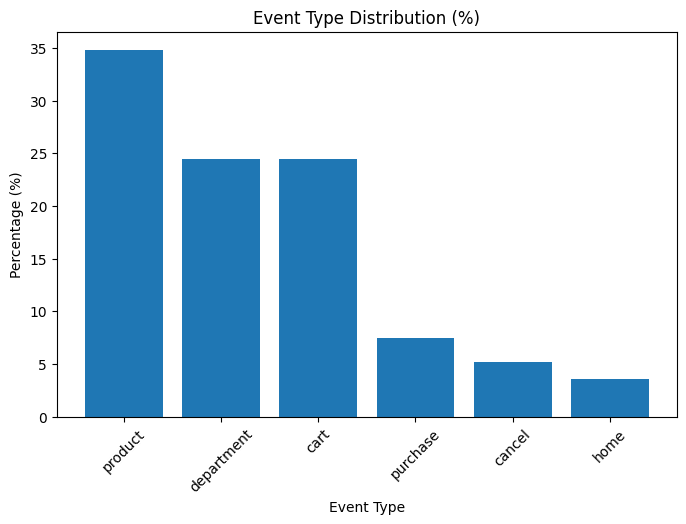

In [40]:
import matplotlib.pyplot as plt

pct = (events['event_type'].value_counts(normalize=True) * 100).round(2)

plt.figure(figsize=(8,5))
plt.bar(pct.index, pct.values)
plt.ylabel('Percentage (%)')
plt.xlabel('Event Type')
plt.title('Event Type Distribution (%)')
plt.xticks(rotation=45)
plt.show()

- Product chiếm 35% -> users chủ yếu view product. Trong khi đó, số lượng purchase chỉ chiếm 7% <br>
- Cancel có tỷ lệ 5% <br>
-> Why?


b. Traffic_source

In [41]:
events['traffic_source'].isna().sum()

np.int64(0)

In [42]:
events['traffic_source'].unique()

<ArrowStringArray>
['YouTube', 'Email', 'Adwords', 'Organic', 'Facebook']
Length: 5, dtype: str

In [43]:
events['traffic_source'].value_counts()

traffic_source
Email       1089665
Adwords      723669
Facebook     244141
YouTube      243578
Organic      119608
Name: count, dtype: int64

In [44]:
events['traffic_source'].value_counts(normalize=True)*100

traffic_source
Email       45.015184
Adwords     29.895512
Facebook    10.085716
YouTube     10.062458
Organic      4.941130
Name: proportion, dtype: float64

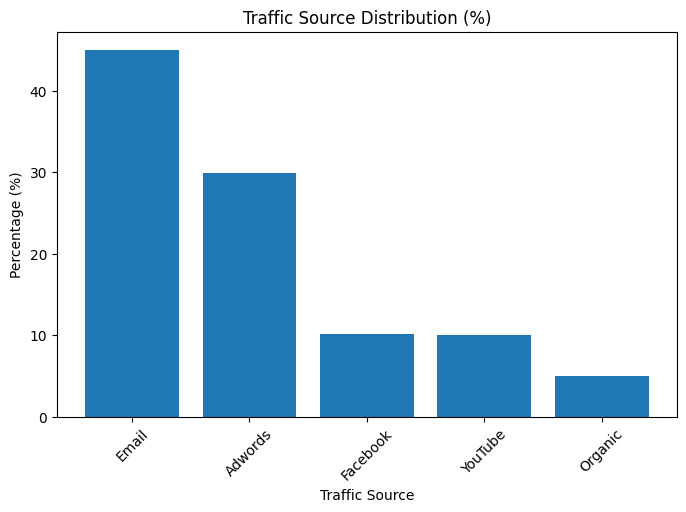

In [45]:

pct_traffic = (events['traffic_source'].value_counts(normalize=True) * 100).round(2)

plt.figure(figsize=(8,5))
plt.bar(pct_traffic.index, pct_traffic.values)
plt.ylabel('Percentage (%)')
plt.xlabel('Traffic Source')
plt.title('Traffic Source Distribution (%)')
plt.xticks(rotation=45)
plt.show()

- Users đến web/app qua email nhiều nhất, tự tìm kiếm (organic ít nhất) <br>
- Users đến qua social như FB, YT có tỷ lệ tương đương nhau

c. Browser

In [46]:
events['browser'].isna().sum()

np.int64(0)

In [47]:
events['browser'].unique()

<ArrowStringArray>
['Chrome', 'Safari', 'IE', 'Firefox', 'Other']
Length: 5, dtype: str

In [48]:
events['browser'].value_counts()

browser
Chrome     1210131
Firefox     485322
Safari      484757
Other       121096
IE          119355
Name: count, dtype: int64

In [49]:
events['browser'].value_counts(normalize=True)*100

browser
Chrome     49.991758
Firefox    20.049152
Safari     20.025811
Other       5.002601
IE          4.930678
Name: proportion, dtype: float64

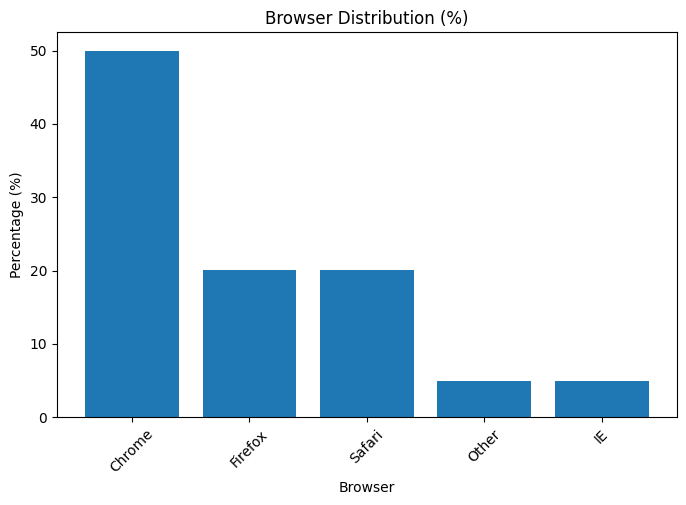

In [50]:

pct_browser = (events['browser'].value_counts(normalize=True) * 100).round(2)

plt.figure(figsize=(8,5))
plt.bar(pct_browser.index, pct_browser.values)
plt.ylabel('Percentage (%)')
plt.xlabel('Browser')
plt.title('Browser Distribution (%)')
plt.xticks(rotation=45)
plt.show()

- Users dùng Chrome chiếm 50% tổng số.

d. Others

In [51]:
events['user_id'].isna().sum()

np.int64(1124527)

In [52]:
events['user_id'].notna().sum()

np.int64(1296134)

In [53]:
# Số lượng users duy nhất
print(f'The number of unique users is: {len(events['user_id'].unique())}')

The number of unique users is: 80096


In [54]:
events['session_id'].isna().sum()

np.int64(0)

In [55]:
# Số lượng session duy nhất
print(f'The number of unique sessions is: {len(events['session_id'].unique())}')

The number of unique sessions is: 680862


In [56]:
# Trung bình mỗi user có bao nhiêu session
session_per_user = events.groupby('user_id')['session_id'].nunique().mean()
print(session_per_user)

2.258093513952182


In [57]:
events.columns

Index(['id', 'user_id', 'sequence_number', 'session_id', 'created_at',
       'ip_address', 'city', 'state', 'postal_code', 'browser',
       'traffic_source', 'uri', 'event_type'],
      dtype='str')

In [58]:
# Trung bình mỗi session có bao nhiêu event_type
event_per_session = events.groupby('session_id')['event_type'].nunique().mean()
print(event_per_session)

2.84254518536796


In [59]:
events['created_at']

0         2019-04-26 16:02:00+00:00
1         2022-10-05 16:56:00+00:00
2         2021-02-17 04:35:00+00:00
3         2024-04-07 04:52:00+00:00
4         2023-09-14 15:20:00+00:00
                     ...           
2420656   2023-12-21 13:06:26+00:00
2420657   2023-10-02 14:45:24+00:00
2420658   2023-11-08 07:48:08+00:00
2420659   2024-03-01 09:04:11+00:00
2420660   2023-07-25 14:09:51+00:00
Name: created_at, Length: 2420661, dtype: datetime64[us, UTC]

In [60]:
events['year'] = events['created_at'].dt.year
events['month'] = events['created_at'].dt.to_period('M')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24412\2917603436.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  events['month'] = events['created_at'].dt.to_period('M')


In [61]:
# Đếm số events mỗi năm
events_per_year = events.groupby('year').size()

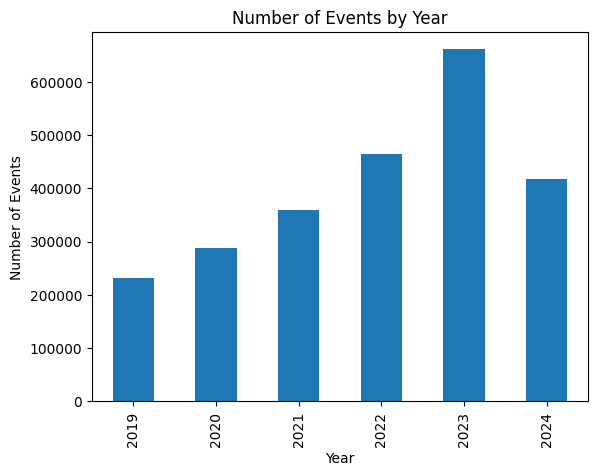

In [62]:
import matplotlib.pyplot as plt

events_per_year.plot(kind='bar')

plt.title('Number of Events by Year')
plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.show()

Xu hướng tổng thể traffic tăng dần theo năm. 2024 thấp vì data chỉ đến tháng 5/2024 (chưa đủ)

In [63]:
events_per_month = events.groupby('month').size()

In [64]:
events_per_month

month
2019-01     17407
2019-02     16385
2019-03     18707
2019-04     18480
2019-05     19054
            ...  
2024-01     73328
2024-02     75676
2024-03     89208
2024-04    107486
2024-05     71797
Freq: M, Length: 65, dtype: int64

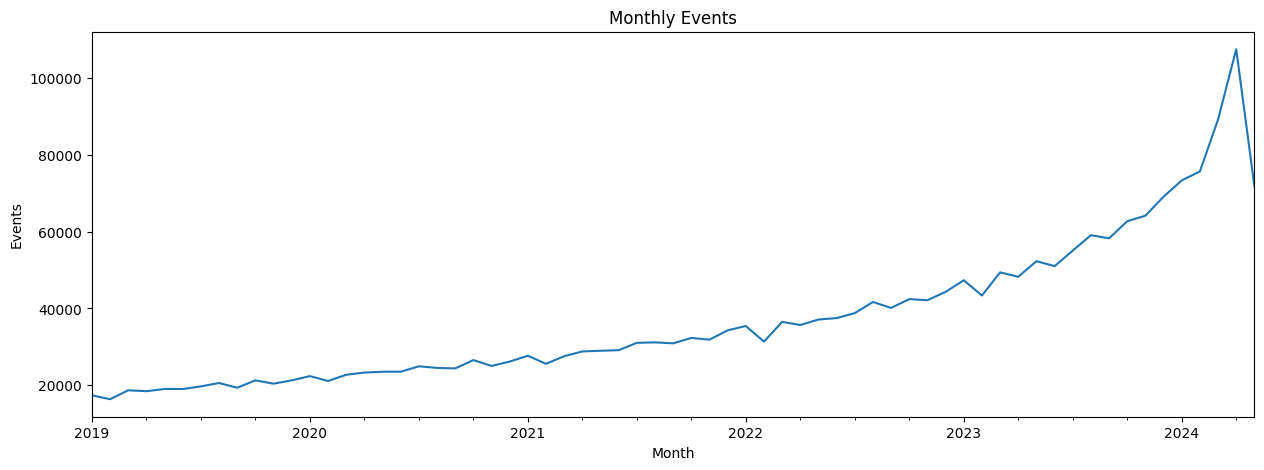

In [65]:
plt.figure(figsize=(15,5))

events_per_month.plot()

plt.title('Monthly Events')
plt.xlabel('Month')
plt.ylabel('Events')

plt.grid(False)

plt.show()

##### 2. Table users

In [66]:
users.columns

Index(['id', 'first_name', 'last_name', 'email', 'age', 'gender', 'state',
       'street_address', 'postal_code', 'city', 'country', 'latitude',
       'longitude', 'traffic_source', 'created_at'],
      dtype='str')

In [67]:
users['age'].describe()

count    100000.000000
mean         41.060310
std          17.067162
min          12.000000
25%          26.000000
50%          41.000000
75%          56.000000
max          70.000000
Name: age, dtype: float64

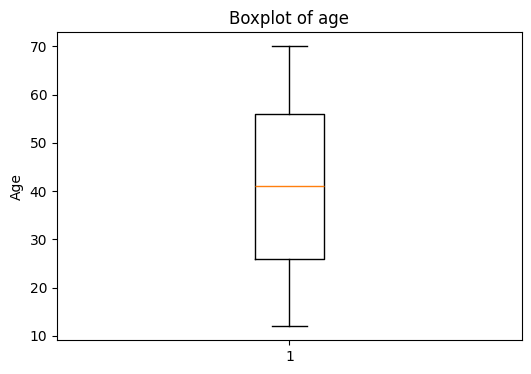

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.boxplot(users['age'])
plt.title('Boxplot of age')
plt.ylabel('Age')
plt.show()

In [69]:
users['age_group'] = pd.cut(
    users['age'],
    bins=[0, 18, 25, 35, 45, 55, float('inf')],
    right=False,
    labels=['<18','18-24', '25-34', '35-44', '45-54', '55+']
)

users['age_group'].value_counts().sort_index()

age_group
<18      10125
18-24    11926
25-34    16818
35-44    16828
45-54    16898
55+      27405
Name: count, dtype: int64

In [70]:
users['gender'].value_counts()

gender
M    50148
F    49852
Name: count, dtype: int64

In [71]:
users['country'].unique()

<ArrowStringArray>
[        'Brasil',          'Japan',  'United States',       'Colombia',
          'Spain',          'China',      'Australia',         'France',
        'Germany',        'Belgium',    'South Korea',         'Poland',
 'United Kingdom',    'Deutschland',         'España']
Length: 15, dtype: str

In [72]:
users['country'].value_counts()

country
China             33893
United States     22309
Brasil            14669
South Korea        5328
United Kingdom     4678
France             4612
Germany            4248
Spain              4065
Japan              2471
Australia          2234
Belgium            1227
Poland              252
Colombia             11
España                2
Deutschland           1
Name: count, dtype: int64

In [73]:
users['country'].value_counts(normalize=True)*100

country
China             33.893
United States     22.309
Brasil            14.669
South Korea        5.328
United Kingdom     4.678
France             4.612
Germany            4.248
Spain              4.065
Japan              2.471
Australia          2.234
Belgium            1.227
Poland             0.252
Colombia           0.011
España             0.002
Deutschland        0.001
Name: proportion, dtype: float64

In [74]:
users['traffic_source'].unique()

<ArrowStringArray>
['Search', 'Display', 'Organic', 'Email', 'Facebook']
Length: 5, dtype: str

In [75]:
users['traffic_source'].value_counts()

traffic_source
Search      70066
Organic     14951
Facebook     5987
Email        4994
Display      4002
Name: count, dtype: int64

In [76]:
users['traffic_source'].value_counts(normalize=True)*100

traffic_source
Search      70.066
Organic     14.951
Facebook     5.987
Email        4.994
Display      4.002
Name: proportion, dtype: float64

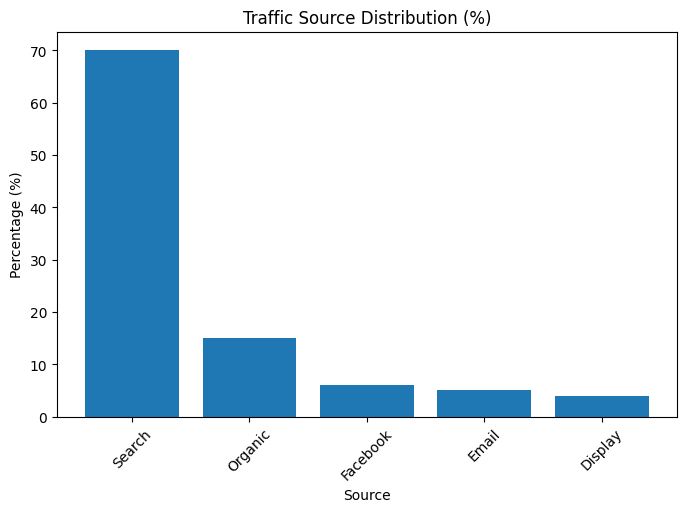

In [77]:
pct_ut = (users['traffic_source'].value_counts(normalize=True) * 100).round(2)

plt.figure(figsize=(8,5))
plt.bar(pct_ut.index, pct_ut.values)
plt.ylabel('Percentage (%)')
plt.xlabel('Source')
plt.title('Traffic Source Distribution (%)')
plt.xticks(rotation=45)
plt.show()

##### 3. Table orders, order_items và products

In [78]:
orders.columns

Index(['order_id', 'user_id', 'status', 'gender', 'created_at', 'returned_at',
       'shipped_at', 'delivered_at', 'num_of_item'],
      dtype='str')

In [79]:
orders['status'].unique()

<ArrowStringArray>
['Cancelled', 'Complete', 'Processing', 'Returned', 'Shipped']
Length: 5, dtype: str

In [80]:
orders['status'].value_counts(normalize=True)*100

status
Shipped       30.114410
Complete      25.179868
Processing    19.774224
Cancelled     14.965469
Returned       9.966029
Name: proportion, dtype: float64

In [81]:
# Số lượng items mỗi order
item_per_order = orders.groupby('order_id')['num_of_item'].sum().mean()
print(item_per_order)

1.4490521896582114


In [82]:
order_items.columns

Index(['id', 'order_id', 'user_id', 'product_id', 'inventory_item_id',
       'status', 'created_at', 'shipped_at', 'delivered_at', 'returned_at',
       'sale_price'],
      dtype='str')

In [83]:
order_items['sale_price'].describe()

count    180862.000000
mean         59.693776
std          66.880191
min           0.020000
25%          24.950001
50%          39.990002
75%          69.949997
max         999.000000
Name: sale_price, dtype: float64

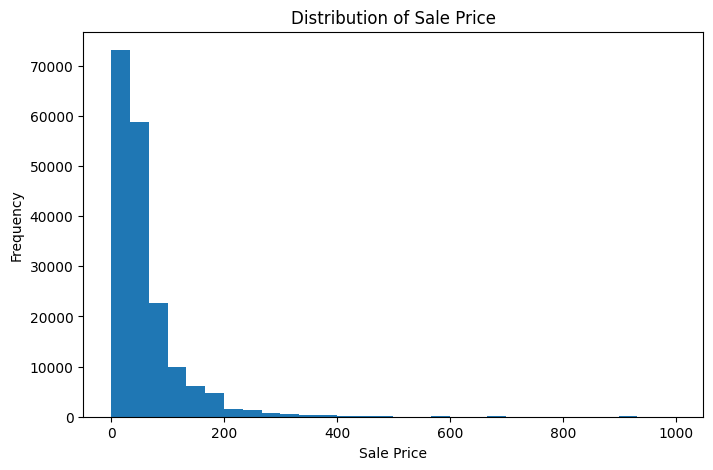

In [84]:
plt.figure(figsize=(8,5))
plt.hist(order_items['sale_price'], bins=30)

plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')

plt.show()

Phân phối lệch trái, chủ yếu tập trung vào các sản phẩm giá từ 0-100$, rất ít sản phẩm giá cao (outliers)

Kiểm tra status

In [85]:
order_items['status'].value_counts(normalize=True) * 100

status
Shipped       30.109144
Complete      25.114175
Processing    19.833354
Cancelled     14.968318
Returned       9.975009
Name: proportion, dtype: float64

In [86]:
print(order_items['created_at'].min())
print(order_items['created_at'].max())

2019-01-09 03:58:22+00:00
2024-05-13 17:53:48.103510+00:00


Revenue từ completed items

In [87]:
completed = order_items[order_items['status'] =='Complete']
total_revenue = completed['sale_price'].sum()
print(f'Total revenue from completed orders is ${total_revenue:.2f}')
print(f"Avg Order Value: ${completed.groupby('order_id')['sale_price'].sum().mean():,.2f}")

Total revenue from completed orders is $2729363.48
Avg Order Value: $86.84


In [88]:
products.columns

Index(['id', 'cost', 'category', 'name', 'brand', 'retail_price', 'department',
       'sku', 'distribution_center_id'],
      dtype='str')

In [89]:
products['category'].unique()

<ArrowStringArray>
[                  'Accessories',                          'Plus',
                          'Swim',                        'Active',
               'Socks & Hosiery',                         'Socks',
                       'Dresses',                'Pants & Capris',
 'Fashion Hoodies & Sweatshirts',                        'Skirts',
             'Blazers & Jackets',                         'Suits',
                   'Tops & Tees',                      'Sweaters',
                        'Shorts',                         'Jeans',
                     'Maternity',                'Sleep & Lounge',
           'Suits & Sport Coats',                         'Pants',
                     'Intimates',             'Outerwear & Coats',
                     'Underwear',                      'Leggings',
           'Jumpsuits & Rompers',                 'Clothing Sets']
Length: 26, dtype: str

In [90]:
products['category'].value_counts()

category
Intimates                        2363
Jeans                            1999
Tops & Tees                      1868
Fashion Hoodies & Sweatshirts    1866
Swim                             1798
Sleep & Lounge                   1771
Shorts                           1765
Sweaters                         1737
Accessories                      1559
Active                           1432
Outerwear & Coats                1420
Underwear                        1088
Pants                            1041
Dresses                           955
Socks                             905
Maternity                         898
Plus                              758
Suits & Sport Coats               739
Socks & Hosiery                   666
Pants & Capris                    613
Leggings                          564
Blazers & Jackets                 561
Skirts                            367
Suits                             188
Jumpsuits & Rompers               162
Clothing Sets                      37
Nam

In [91]:
products['department'].unique()

<ArrowStringArray>
['Women', 'Men']
Length: 2, dtype: str

In [92]:
products['department'].value_counts()

department
Women    15989
Men      13131
Name: count, dtype: int64